### AirBnB: Natural Language Processing 
Extracting the underlying vibe and emotion of each listing within our dataset. 

In [144]:
import pandas as pd
import numpy as np

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from collections import defaultdict

In [58]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/alexkramer/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alexkramer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/alexkramer/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/alexkramer/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

#### Load in Dataset

In [32]:
# to run this code on a different set of data, change the file name below
file_name = "Output.csv"
df = pd.read_csv(file_name)

In [33]:
# check to make sure output file is correct
df.columns

Index(['id', 'listing_url', 'name', 'description', 'neighborhood_overview',
       'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates',
       'amenities'],
      dtype='object')

In [34]:
# show example of row 
df.iloc[0].T

id                                                                  1913774
listing_url                            https://www.airbnb.com/rooms/1913774
name                                       Downtown Bozeman Vacation Rental
description               Just four easy blocks from historic downtown B...
neighborhood_overview                                                   NaN
neighbourhood_cleansed                                              Bozeman
property_type                                             Entire guesthouse
room_type                                                   Entire home/apt
accommodates                                                              2
amenities                 ["Shower gel", "Essentials", "Hair dryer", "Ex...
Name: 0, dtype: object

#### Null Value Handling

In [35]:
# dataset shape
print("Shape:", df.shape)

# check description missing values
df["description"].isna().sum()

Shape: (17422, 10)


295

In [36]:
### question for team: do we want to subsitute the description data
#  for something else if their is no description data?

# drop empty descriptions
df = df.dropna(subset=["description"])
df["description"].isna().sum()

0

#### Understanding our description data

In [37]:
# Description Length

# create new field that shows legnth of description 
df["desc_char_length"] = df["description"].apply(len)
df["desc_char_length"].describe

<bound method NDFrame.describe of 0        265
1         74
2        205
3        337
4        285
        ... 
17417    435
17418    354
17419    365
17420    574
17421    537
Name: desc_char_length, Length: 17127, dtype: int64>

In [38]:
# Description word count
df["desc_word_count"] = df["description"].apply(lambda x: len(str(x).split()))
df["desc_word_count"].describe()


count    17127.000000
mean        66.081626
std         21.631261
min          1.000000
25%         56.000000
50%         73.000000
75%         81.000000
max        179.000000
Name: desc_word_count, dtype: float64

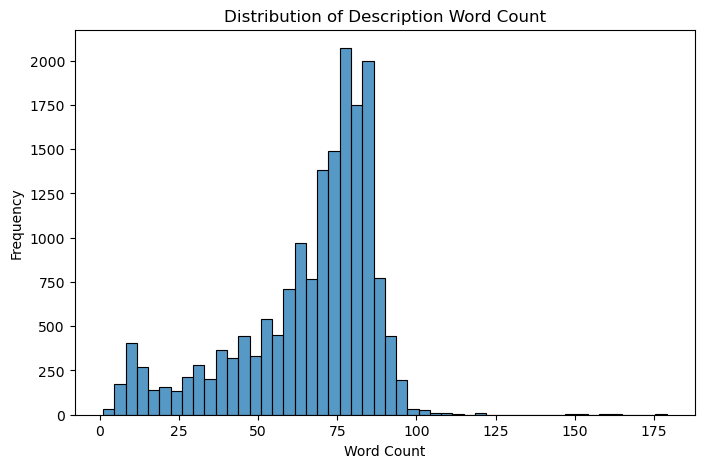

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df["desc_word_count"], bins=50)
plt.title("Distribution of Description Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#### Examin Descriptions - Random Sample

In [40]:
for i, desc in enumerate(df["description"].sample(5, random_state=42)):
    print(f"\n--- Sample {i+1} ---")
    print(desc[:1000])  # limit to first 1000 characters



--- Sample 1 ---
Steps from the legendary HOLLYWOOD BOARDWALK overlooking a beautiful beach surrounded by bars, live music events, and wonderful restaurants . This MODERN CONDO RESORT w/ a POOL, Hot Tub, Gym and Sun Deck fulfills your dream of an amazing vacation. Master room with a King-Sized Bed and a second room with a king-Sized Bed, Two Bathrooms, Living Room  with 1 Comfortable Full Pullout Sofa Bed and BALCONY.<br /><br />Resort fee will be charged at the check-in time at the property and it is not included.

--- Sample 2 ---
Oversized 1 bedroom, 1 bathroom, 2nd floor apartment located 1 block west of the beach. Perfect home base for remote workers or guests relocating to South Florida. Connect your devices to the fastest internet - speeds up to 1300mbps. Watch over 100+ Xfinity cable channels or stream your favorite shows on the 55" smart Samsung TV.  Fully stocked kitchen. 2 shared outdoor spaces with 2 BBQ grills. The bedroom includes a queen size Casper memory foam mattress

### Longest + Shortest 


In [41]:
# Longest description
df.sort_values("desc_word_count", ascending=False)[["desc_word_count", "description"]].head(5)

,desc_word_count,description
1913,179,Today’s weather? 75 and sunny! So come grab yo...
8203,177,Beautiful newly renovated home in the heart of...
5909,173,This is a newly built 1 bedroom 1 bathroom pla...
1278,168,The best of both worlds....Large trendy and up...
7971,163,"2 Bedroom, 2 bathroom unit located in Hollywoo..."


In [42]:
# Shortest description
df.sort_values("desc_word_count")[["desc_word_count", "description"]].head(5)

,desc_word_count,description
10319,1,home
4949,1,nnnnnnnnnnnnnnnn
1974,2,deluxe king
13191,2,Queen Room
2998,2,complete decoration


### Check descriptions for special characters

In [43]:
# Look for HTML tags
df["description"].str.contains("<").sum()

7991

In [44]:
# check for any non ASCII -- American Standard for Code Information Interchaneg 
# looking for dashes, curls, emojis, etc. 

def contains_special_chars(text):
    return bool(re.search(r"[^\x00-\x7F]+", str(text)))

df["has_non_ascii"] = df["description"].apply(contains_special_chars)
df["has_non_ascii"].sum()

4117

### Text Cleaning Pipeline

In [89]:
# nlp base stopwords
stop_words = set(stopwords.words("english"))

# Airbnb-specific stop words --- to increase as testing goes
airbnb_stopwords = {
    "bedroom", "bed", "bathroom", "bath",
    "wifi", "kitchen", "parking", "apartment",
    "house", "stay", "guest", "guests",
    "night", "check", "home", "floor",
    "block", "minute", "walk", "away",
    "located", "include", "includes",
    "full", "size", "queen", "king",
    "tv", "smart", "internet", "ac"
}

additional_stopwords = {
    "permit", "registration", "law", "according",
    "number", "str", "post", "inquire",
    "checkin", "checkout", "airport",
    "drive", "downtown", "block",
    "location", "minute", "please",
    "family", "kid", "large", "self", "youre",
    "minutes", "chair", "ceiling", "amenities", "end", "heated"
}

admin_stopwords = {
    "permit", "registration", "law", "according",
    "number", "str", "post", "detail",
    "checkin", "checkout",
    "airport", "drive", "block",
    "location", "minute",
    "please", "inquire",
    "family", "kid", "large",
    "best", "great", "offer",
    "space", "designed",
    "available", "provide",
    "block", "street", "yard", "campus", "town",
    "side", "floor", "unit", "building",
    "minute", "need", "detail", "people",
    "sleep", "fee", "resort", "amenity",
    "remote", "keyless", "self",
    "basic", "fine", "top", "best", "amenities"
}

city_unigrams = {
    "bozeman"
}

city_bigrams = {
    "fort lauderdale"
}

# should we remove marketing words? 
# perfect, amazing, etc.

# Combine
all_stopwords = (
    stop_words
    .union(airbnb_stopwords)
    .union(admin_stopwords)
    .union(city_unigrams)
)
print('hi')

hi


In [90]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove non-ASCII
    text = text.encode("ascii", "ignore").decode()
    
    # Remove city bigrams
    for city in city_bigrams:
        text = text.replace(city, "")
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in all_stopwords]
    
    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Remove short words
    tokens = [word for word in tokens if len(word) > 2]
    
    return tokens

In [91]:
df["clean_tokens"] = df["description"].apply(clean_text)

In [66]:
df["clean_text"] = df["clean_tokens"].apply(lambda x: " ".join(x))

In [53]:
for i in range(3):
    print("\n--- ORIGINAL ---")
    print(df["description"].iloc[i][:500])
    
    print("\n--- CLEANED TOKENS ---")
    print(df["clean_tokens"].iloc[i][:20])


--- ORIGINAL ---
Just four easy blocks from historic downtown Bozeman, this modern loft apartment is your perfect retreat. Enjoy a private loft, with modern amenities, just minutes from the best that Bozeman has to offer, shopping, fine dining, and nightlife.<br /><br />STR22-00028

--- CLEANED TOKENS ---
['four', 'easy', 'block', 'historic', 'downtown', 'modern', 'loft', 'perfect', 'retreat', 'enjoy', 'private', 'loft', 'modern', 'amenity', 'minute', 'shopping', 'fine', 'dining', 'nightlife']

--- ORIGINAL ---
Free, fast Wi-Fi for remote learning/working needs. Keyless self check-in.

--- CLEANED TOKENS ---
['free', 'fast', 'remote', 'learningworking', 'need', 'keyless', 'self']

--- ORIGINAL ---
This space is designed for 1-2 people that want to sleep in the same bed.  More details are below.<br /><br />According to our local laws, I need to post my registration number -  Registration #STR22-00083

--- CLEANED TOKENS ---
['people', 'want', 'sleep', 'detail', 'local', 'law', 'need']


#### TF-IDF: Comparing Unigrams, Bigrams and Unigrams + Bigrams

In [54]:
tfidf_uni = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=5000,
    min_df=5
)

X_uni = tfidf_uni.fit_transform(df["clean_text"])

In [ ]:
tfidf_bi = TfidfVectorizer(
    ngram_range=(2,2),
    max_features=5000,
    min_df=5
)

X_bi = tfidf_bi.fit_transform(df["clean_text"])

In [55]:
tfidf_uni_bi = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=7000,
    min_df=5
)

X_uni_bi = tfidf_uni_bi.fit_transform(df["clean_text"])

In [56]:
def extract_top_terms(tfidf_matrix, vectorizer, row_index, top_n=5):
    
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    row = tfidf_matrix[row_index].toarray().flatten()
    
    top_indices = row.argsort()[-top_n:][::-1]
    
    return feature_names[top_indices]

Unigrams alone: Too generic (town, location, great)

Bigrams alone: Too sparse and noisy

Combined: Has the best expressive potentia

Note: We compared unigram and bigram TF-IDF extraction to evaluate whether multi-word phrases better capture listing ‘vibe’. Bigrams improved contextual specificity (e.g., ‘river rock fireplace’) but increased sparsity. A combined n-gram approach provided the best interpretability.

In [57]:
for i in range(5):
    print(f"\n================ Listing {i} ================\n")
    
    print("UNIGRAMS:")
    print(extract_top_terms(X_uni, tfidf_uni, i))
    
    print("\nBIGRAMS:")
    print(extract_top_terms(X_bi, tfidf_bi, i))
    
    print("\nUNIGRAM + BIGRAM:")
    print(extract_top_terms(X_uni_bi, tfidf_uni_bi, i))


================ Listing 0 ================

UNIGRAMS:
['loft' 'fine' 'modern' 'historic' 'four']

BIGRAMS:
['minute best' 'historic downtown' 'retreat enjoy' 'bozeman offer'
 'fine dining']

UNIGRAM + BIGRAM:
['loft' 'historic downtown' 'retreat enjoy' 'minute shopping'
 'fine dining']

================ Listing 1 ================

UNIGRAMS:
['learningworking' 'keyless' 'self' 'remote' 'fast']

BIGRAMS:
['free fast' 'self checkin' 'zen garden' 'family quiet' 'family kid']

UNIGRAM + BIGRAM:
['free fast' 'keyless' 'self' 'remote' 'fast']

================ Listing 2 ================

UNIGRAMS:
['detail' 'want' 'people' 'sleep' 'local']

BIGRAMS:
['space designed' 'zen garden' 'family great' 'family kid' 'family large']

UNIGRAM + BIGRAM:
['detail' 'want' 'people' 'sleep' 'local']

================ Listing 3 ================

UNIGRAMS:
['town' 'specific' 'campus' 'porch' 'entertaining']

BIGRAMS:
['please inquire' 'bathroom large' 'drive airport' 'fenced yard'
 'zen garden']

UNIGRAM + B

Note: TF-IDF was not able to filter as advance as we had hoped -- testing POS filtering next. 

#### POS Filtering

In [92]:
def clean_text_adj_noun(text):
    
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = text.encode("ascii", "ignore").decode()
    
    for city in city_bigrams:
        text = text.replace(city, "")
    
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in all_stopwords]
    
    tagged = pos_tag(tokens)
    
    phrases = []
    
    for i in range(len(tagged) - 1):
        word1, tag1 = tagged[i]
        word2, tag2 = tagged[i + 1]
        
        if tag1.startswith("JJ") and tag2.startswith("NN"):
            phrases.append(f"{word1}_{word2}")  # underscore instead of space
    
    return phrases

In [93]:
df["vibe_phrases"] = df["description"].apply(clean_text_adj_noun)
df["vibe_text"] = df["vibe_phrases"].apply(lambda x: " ".join(x))

In [94]:
tfidf_phrase = TfidfVectorizer(
    max_features=5000,
    min_df=50
)

X_phrase = tfidf_phrase.fit_transform(df["vibe_text"])

In [95]:
for i in range(5):
    print(f"\n================ Listing {i} ================\n")
    print(extract_top_terms(X_phrase, tfidf_phrase, i))


================ Listing 0 ================

['perfect_retreat' 'young_circle' 'hot_tubs' 'lauderdale_sea'
 'lauderdale_beach']

================ Listing 1 ================

['young_circle' 'free_gym' 'lauderdale_sea' 'lauderdale_beach' 'las_olas']

================ Listing 2 ================

['young_circle' 'free_gym' 'lauderdale_sea' 'lauderdale_beach' 'las_olas']

================ Listing 3 ================

['young_circle' 'free_gym' 'lauderdale_sea' 'lauderdale_beach' 'las_olas']

================ Listing 4 ================

['young_circle' 'free_gym' 'lauderdale_sea' 'lauderdale_beach' 'las_olas']


In [97]:
# See how similar they are by word overlap
def jaccard(a, b):
    a, b = set(str(a).lower().split()), set(str(b).lower().split())
    return len(a & b) / max(1, len(a | b))

for i in range(1,5):
    print(i, jaccard(df.loc[0, "description"], df.loc[i, "description"]))


1 0.0
2 0.09523809523809523
3 0.06097560975609756
4 0.19672131147540983


#### POS Fixed Filtering

In [100]:
def clean_text_pos_no_proper(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = text.encode("ascii", "ignore").decode()

    for city in city_bigrams:
        text = text.replace(city, "")

    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]

    tagged = pos_tag(tokens)

    # keep adjectives + common nouns only, drop proper nouns
    keep = []
    for w, tag in tagged:
        if tag.startswith("JJ") or tag in ("NN", "NNS"):
            keep.append(lemmatizer.lemmatize(w))

    return keep

In [101]:
df["clean_tokens_pos2"] = df["description"].apply(clean_text_pos_no_proper)
df["clean_text_pos2"] = df["clean_tokens_pos2"].apply(lambda x: " ".join(x))

In [102]:
tfidf_pos2 = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=10,     # ignore very rare junk
    max_df=0.20,   # ignore overly common boilerplate (20% of docs)
    max_features=8000
)
X_pos2 = tfidf_pos2.fit_transform(df["clean_text_pos2"])

In [103]:
test_idx = df.sample(5, random_state=42).index
for i in test_idx:
    print(f"\n================ Listing {i} ================\n")
    print(extract_top_terms(X_pos2, tfidf_pos2, i))


================ Listing 16256 ================

['bed perfect' 'pool villa' 'space ideal' 'area youre' 'minute attraction']

================ Listing 6168 ================

['min' 'apartment right' 'shore beautiful' 'welcome bottom'
 'tropical unique']

================ Listing 123 ================

['court' 'deck' 'club' 'gas fireplace' 'pickle ball']

================ Listing 4814 ================

['youll' 'make sure' 'resortlike' 'pool hollywood' 'hot spot']

================ Listing 4676 ================

['minute beach' 'perfect minute' 'mall minute' 'casino minute'
 'minute mall']


In [106]:
all_terms = " ".join(df["clean_text_pos2"].dropna()).split()
Counter(all_terms).most_common(30)

[('beach', 13722),
 ('pool', 7296),
 ('private', 6411),
 ('room', 5989),
 ('minute', 4910),
 ('view', 4372),
 ('restaurant', 4348),
 ('perfect', 3849),
 ('area', 3842),
 ('enjoy', 3790),
 ('spacious', 3303),
 ('access', 3195),
 ('hollywood', 3105),
 ('beautiful', 2950),
 ('ocean', 2931),
 ('modern', 2745),
 ('place', 2682),
 ('welcome', 2618),
 ('vacation', 2556),
 ('mile', 2442),
 ('day', 2433),
 ('free', 2279),
 ('property', 2249),
 ('florida', 2226),
 ('step', 2221),
 ('min', 2130),
 ('comfort', 2088),
 ('offer', 2074),
 ('living', 2037),
 ('balcony', 2036)]

TDIF did not work even with POS filtering -- because all these listings are so similar

### Extracting 

In [129]:
base_stopwords = set(stopwords.words("english"))

# Multi-word places to remove *before* tokenization
CITY_BIGRAMS = {
    "fort lauderdale",
}

# Single-token places to remove (extend as needed)
PLACE_TOKENS = {
    "bozeman", "lauderdale", "hallandale", "hollywood", "olas", "isles", "bay", "waterway", "florida"
}

# Airbnb / housing functional words you don't want as vibe
AIRBNB_FUNCTIONAL = {
    "bedroom", "bathroom", "wifi", "kitchen", "parking", "apartment", "condo", "house",
    "guest", "guests", "stay", "checkin", "checkout", "night", "nights",
    "queen", "king", "tv", "internet", "ac"
}

# Utility/amenity nouns (keep or drop depending on your definition of “vibe”)
UTILITY_NOUNS = {
    "pool", "tub", "washer", "dryer", "bed", "beds", "room", "entrance", "cabanas",
    "access", "speed", "chair", "ceiling", "closet", "sofa", "tv", "bath", "bathroom", "airport"
}

# Generic marketing / filler terms
MARKETING_WORDS = {
    "perfect", "local", "whole", "best", "great", "ideal", "welcome"
}

# Weak nouns that create low-signal phrases (e.g., open_plan, private_enjoy)
WEAK_NOUNS = {
    "plan", "enjoy", "spot", "place", "thing", "area", "array", "link"
}

EXACT_PHRASE_BLOCKLIST = {
    "hard_rock", "full_bath", "full_bathroom", "smart_tv", "international_airport", "fll_airport", "full_kitchen",
    "modern_kitchen"
}

# Combine stopwords used at token level
ALL_STOPWORDS = base_stopwords.union(AIRBNB_FUNCTIONAL).union(MARKETING_WORDS).union(PLACE_TOKENS)

In [122]:
def normalize_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # remove HTML
    text = re.sub(r"<.*?>", " ", text)
    # remove non-ascii
    text = text.encode("ascii", "ignore").decode()
    # remove multi-word cities
    for city in CITY_BIGRAMS:
        text = text.replace(city, " ")
    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # remove numbers
    text = re.sub(r"\d+", " ", text)
    # collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
def extract_adj_noun_phrases(text: str) -> list[str]:
    text = normalize_text(text)
    if not text:
        return []

    tokens = word_tokenize(text)
    # basic token filtering
    tokens = [t for t in tokens if len(t) > 2 and t not in ALL_STOPWORDS]

    tagged = pos_tag(tokens)

    phrases = []
    for i in range(len(tagged) - 1):
        w1, t1 = tagged[i]
        w2, t2 = tagged[i + 1]

        # adjective + noun (common noun only)
        if t1.startswith("JJ") and (t2 == "NN" or t2 == "NNS"):
            w1 = lemmatizer.lemmatize(w1)
            w2 = lemmatizer.lemmatize(w2)
            phrases.append(f"{w1}_{w2}")

    return phrases

In [130]:
def keep_vibe_phrase(phrase: str) -> bool:
    if phrase in EXACT_PHRASE_BLOCKLIST:
        return False

    parts = phrase.split("_")
    if len(parts) != 2:
        return False

    adj, noun = parts

    if adj in PLACE_TOKENS or noun in PLACE_TOKENS:
        return False

    if noun in UTILITY_NOUNS:
        return False

    if noun in WEAK_NOUNS:
        return False

    if adj in MARKETING_WORDS:
        return False

    return True

In [125]:
def listing_vibe_keywords(description: str, top_n: int = 5) -> list[str]:
    phrases = extract_adj_noun_phrases(description)
    phrases = [p for p in phrases if keep_vibe_phrase(p)]
    if not phrases:
        return []
    return [p for p, _ in Counter(phrases).most_common(top_n)]

In [131]:
df = df.dropna(subset=["description"]).copy()

df["vibe_phrases_raw"] = df["description"].apply(extract_adj_noun_phrases)
df["vibe_phrases"] = df["vibe_phrases_raw"].apply(lambda lst: [p for p in lst if keep_vibe_phrase(p)])
df["vibe_keywords"] = df["description"].apply(lambda x: listing_vibe_keywords(x, top_n=5))

In [132]:
def pretty_phrases(phrases):
    return [p.replace("_", " ") for p in phrases]

df["vibe_keywords_pretty"] = df["vibe_keywords"].apply(pretty_phrases)

df[["vibe_keywords_pretty"]].sample(5, random_state=42)

,vibe_keywords_pretty
16256,"[legendary boardwalk, beautiful beach, live mu..."
6168,"[oversized floor, west beach, remote worker, c..."
123,"[aspen brook, aspen spruce, riverside country,..."
4814,"[min walk, sun powdery, oceanfront restaurant]"
4676,"[dania beach, quick ride, downtown quaint, inc..."


In [133]:
df[["description", "vibe_keywords_pretty"]].sample(5, random_state=42)

,description,vibe_keywords_pretty
16256,Steps from the legendary HOLLYWOOD BOARDWALK o...,"[legendary boardwalk, beautiful beach, live mu..."
6168,"Oversized 1 bedroom, 1 bathroom, 2nd floor apa...","[oversized floor, west beach, remote worker, c..."
123,Aspen Brook is nestled in an Aspen and Spruce ...,"[aspen brook, aspen spruce, riverside country,..."
4814,Enjoy a stress-free beach-side getaway in our ...,"[min walk, sun powdery, oceanfront restaurant]"
4676,Welcome to the newly renovated Butterfly Cove ...,"[dania beach, quick ride, downtown quaint, inc..."


In [128]:
all_vibes = Counter([p for row in df["vibe_phrases"] for p in row])
all_vibes.most_common(30)

[('ocean_view', 1023),
 ('hard_rock', 1016),
 ('full_bath', 676),
 ('private_balcony', 580),
 ('beautiful_beach', 553),
 ('smart_tv', 453),
 ('full_bathroom', 413),
 ('prime_location', 409),
 ('short_walk', 378),
 ('international_airport', 350),
 ('sunny_beach', 329),
 ('short_drive', 293),
 ('private_beach', 293),
 ('live_music', 285),
 ('quiet_neighborhood', 280),
 ('front_beach', 278),
 ('private_cabana', 254),
 ('relax_family', 237),
 ('full_size', 233),
 ('atlantic_ocean', 230),
 ('wonderful_restaurant', 228),
 ('private_patio', 227),
 ('private_backyard', 223),
 ('spectacular_beachwalk', 214),
 ('fll_airport', 205),
 ('modern_resort', 197),
 ('central_location', 189),
 ('intracoastal_downtown', 186),
 ('spacious_living', 180),
 ('new_luxury', 176)]

#### NRC Emotion Lexicon Sentiment Analysis

1. load nrc as dataframe
2. emotion scoring per listing :
    Tokenize cleaned text
    Count matches for each emotion
    Normalize by word count (important!)
    Store


In [134]:
def tokenize_for_emotion(text: str, remove_stopwords: bool = False, stopwords_set=None) -> list[str]:
    text = normalize_text_for_emotion(text)
    if not text:
        return []
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    if remove_stopwords and stopwords_set is not None:
        tokens = [t for t in tokens if t not in stopwords_set]

    return tokens

In [135]:
def normalize_text_for_emotion(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)                        # HTML
    text = text.encode("ascii", "ignore").decode()            # non-ascii
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)                          # numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [138]:
NRC_PATH = "NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"  # <-- change this

EMOTIONS_8 = ["anger","anticipation","disgust","fear","joy","sadness","surprise","trust"]
POLARITY = ["positive","negative"]
ALL_NRC_CATS = EMOTIONS_8 + POLARITY

In [140]:
with open(NRC_PATH, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(5):
        print(f.readline().rstrip("\n"))

aback	anger	0
aback	anticipation	0
aback	disgust	0
aback	fear	0
aback	joy	0


In [141]:
# 2) Try reading with a few common separators and show columns
for sep in ["\t", ",", ";", "|"]:
    try:
        tmp = pd.read_csv(NRC_PATH, sep=sep, nrows=5, header=None)
        print("\nSEP:", repr(sep), "shape:", tmp.shape)
        display(tmp.head())
    except Exception as e:
        print("\nSEP:", repr(sep), "FAILED:", e)


SEP: '\t' shape: (5, 3)


,0,1,2
0,aback,anger,0
1,aback,anticipation,0
2,aback,disgust,0
3,aback,fear,0
4,aback,joy,0



SEP: ',' shape: (5, 1)


,0
0,aback\tanger\t0
1,aback\tanticipation\t0
2,aback\tdisgust\t0
3,aback\tfear\t0
4,aback\tjoy\t0



SEP: ';' shape: (5, 1)


,0
0,aback\tanger\t0
1,aback\tanticipation\t0
2,aback\tdisgust\t0
3,aback\tfear\t0
4,aback\tjoy\t0



SEP: '|' shape: (5, 1)


,0
0,aback\tanger\t0
1,aback\tanticipation\t0
2,aback\tdisgust\t0
3,aback\tfear\t0
4,aback\tjoy\t0


In [145]:
EMOTIONS_8 = ["anger","anticipation","disgust","fear","joy","sadness","surprise","trust"]
POLARITY = ["positive","negative"]
ALL_NRC_CATS = EMOTIONS_8 + POLARITY

def load_nrc_lexicon_robust(path: str) -> dict[str, set[str]]:
    """
    Robust loader for common NRC lexicon variants.
    Returns dict: category -> set(words)
    """

    # Read raw lines, drop blank + comment lines
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.strip() for ln in f if ln.strip() and not ln.startswith("#")]

    if not lines:
        raise ValueError("NRC file appears empty after removing comments/blank lines.")

    # Detect delimiter by checking first non-comment line
    sample = lines[0]
    if "\t" in sample:
        sep = "\t"
    elif "," in sample:
        sep = ","
    elif ";" in sample:
        sep = ";"
    else:
        sep = None  # whitespace split fallback

    cat_to_words = defaultdict(set)

    def add_pair(word: str, cat: str, assoc: str = "1"):
        word = word.strip().lower()
        cat = cat.strip().lower()
        if cat in ALL_NRC_CATS and assoc.strip() in {"1", "1.0", "true", "True"}:
            cat_to_words[cat].add(word)

    # Try parsing each line as columns
    for ln in lines[:2000000]:  # safety cap; adjust if needed
        parts = ln.split(sep) if sep else ln.split()

        # Common formats:
        # A) word, category, 0/1
        # B) category, word, 0/1
        # C) word, category  (implied assoc=1)
        # D) category, word  (implied assoc=1)

        if len(parts) >= 3:
            a, b, c = parts[0], parts[1], parts[2]
            a_l, b_l = a.lower(), b.lower()

            # decide which is category
            if b_l in ALL_NRC_CATS:
                # word, category, assoc
                add_pair(a, b, c)
            elif a_l in ALL_NRC_CATS:
                # category, word, assoc
                add_pair(b, a, c)
            else:
                # not recognizable row; skip
                continue

        elif len(parts) == 2:
            a, b = parts[0], parts[1]
            a_l, b_l = a.lower(), b.lower()

            if b_l in ALL_NRC_CATS:
                # word, category
                add_pair(a, b, "1")
            elif a_l in ALL_NRC_CATS:
                # category, word
                add_pair(b, a, "1")
            else:
                continue

        else:
            continue

    if not cat_to_words:
        raise ValueError(
            "Could not parse NRC file into (word, category, assoc). "
            "Paste the first 5 lines of the file so we can adapt."
        )

    return dict(cat_to_words)

cat_to_words = load_nrc_lexicon_robust(NRC_PATH)
{c: len(cat_to_words.get(c, set())) for c in ALL_NRC_CATS}

{'anger': 1245,
 'anticipation': 837,
 'disgust': 1056,
 'fear': 1474,
 'joy': 687,
 'sadness': 1187,
 'surprise': 532,
 'trust': 1230,
 'positive': 2308,
 'negative': 3316}

In [148]:
def score_nrc(tokens: list[str], cat_to_words: dict[str, set[str]]) -> dict:
    scores = {cat: 0 for cat in ALL_NRC_CATS}
    if not tokens:
        scores["n_tokens"] = 0
        scores["dominant_emotion"] = None
        return scores

    token_set = tokens  # keep duplicates so repeated emotion words count more
    for t in token_set:
        for cat in ALL_NRC_CATS:
            if t in cat_to_words.get(cat, set()):
                scores[cat] += 1

    scores["n_tokens"] = len(tokens)

    # normalized scores
    for cat in ALL_NRC_CATS:
        scores[f"{cat}_norm"] = scores[cat] / scores["n_tokens"] if scores["n_tokens"] else 0.0

    # dominant among 8 emotions
    emo_counts = {e: scores[e] for e in EMOTIONS_8}
    max_val = max(emo_counts.values()) if emo_counts else 0
    scores["dominant_emotion"] = None if max_val == 0 else max(emo_counts, key=emo_counts.get)

    # optional: simple polarity ratio
    pos = scores["positive"]
    neg = scores["negative"]
    scores["pos_neg_ratio"] = (pos + 1) / (neg + 1)

    return scores

In [149]:
df["emotion_tokens"] = df["description"].apply(
    lambda x: tokenize_for_emotion(x, remove_stopwords=False)
)

emotion_rows = df["emotion_tokens"].apply(
    lambda toks: score_nrc(toks, cat_to_words)
).apply(pd.Series)

df = pd.concat([df, emotion_rows], axis=1)

In [150]:
df["dominant_emotion"].value_counts(dropna=False).head(10)

dominant_emotion
joy             9130
anticipation    4849
trust           2060
anger            475
NaN              376
sadness           90
surprise          79
fear              44
disgust           24
Name: count, dtype: int64

In [151]:
df[[f"{e}_norm" for e in EMOTIONS_8] + ["positive_norm","negative_norm"]].mean().sort_values(ascending=False)

positive_norm        0.129897
joy_norm             0.075065
anticipation_norm    0.054962
trust_norm           0.053034
surprise_norm        0.017760
negative_norm        0.013430
sadness_norm         0.007898
anger_norm           0.006068
fear_norm            0.005272
disgust_norm         0.002051
dtype: float64

In [152]:
df[[
    "vibe_keywords_pretty",
    "dominant_emotion",
    "joy_norm",
    "trust_norm",
    "fear_norm",
    "sadness_norm",
    "positive_norm",
    "negative_norm"
]].sample(5, random_state=42)

,vibe_keywords_pretty,dominant_emotion,joy_norm,trust_norm,fear_norm,sadness_norm,positive_norm,negative_norm
16256,"[legendary boardwalk, beautiful beach, live mu...",joy,0.088235,0.029412,0.000000,0.014706,0.147059,0.014706
6168,"[oversized floor, west beach, remote worker, c...",trust,0.046875,0.078125,0.015625,0.000000,0.062500,0.000000
123,"[aspen brook, aspen spruce, riverside country,...",anticipation,0.028571,0.042857,0.028571,0.000000,0.142857,0.042857
4814,"[min walk, sun powdery, oceanfront restaurant]",joy,0.044776,0.029851,0.000000,0.000000,0.059701,0.014925
4676,"[dania beach, quick ride, downtown quaint, inc...",joy,0.207547,0.150943,0.018868,0.018868,0.169811,0.018868


In [153]:
df["dominant_emotion"].value_counts(normalize=True)

dominant_emotion
joy             0.545042
anticipation    0.289475
trust           0.122978
anger           0.028357
sadness         0.005373
surprise        0.004716
fear            0.002627
disgust         0.001433
Name: proportion, dtype: float64

In [154]:
emotion_cols = [f"{e}_norm" for e in EMOTIONS_8]

df[emotion_cols].mean().sort_values(ascending=False)

joy_norm             0.075065
anticipation_norm    0.054962
trust_norm           0.053034
surprise_norm        0.017760
sadness_norm         0.007898
anger_norm           0.006068
fear_norm            0.005272
disgust_norm         0.002051
dtype: float64

In [155]:
df[["positive_norm","negative_norm"]].mean()

positive_norm    0.129897
negative_norm    0.013430
dtype: float64

#### Check 

In [164]:
df["dominant_emotion"].value_counts()

dominant_emotion
joy             9130
anticipation    4849
trust           2060
anger            475
sadness           90
surprise          79
fear              44
disgust           24
Name: count, dtype: int64

In [165]:
emotion_cols = [f"{e}_norm" for e in EMOTIONS_8]
df[emotion_cols + ["positive_norm","negative_norm"]].mean().sort_values(ascending=False)

positive_norm        0.129897
joy_norm             0.075065
anticipation_norm    0.054962
trust_norm           0.053034
surprise_norm        0.017760
negative_norm        0.013430
sadness_norm         0.007898
anger_norm           0.006068
fear_norm            0.005272
disgust_norm         0.002051
dtype: float64

### Clean Up Final

In [173]:
MAX_VIBES = 5

def pad_vibes(vibes, max_len=MAX_VIBES):
    vibes = vibes[:max_len]
    return vibes + [None] * (max_len - len(vibes))

vibe_cols = df["vibe_keywords_pretty"].apply(lambda x: pad_vibes(x))

vibe_df = pd.DataFrame(
    vibe_cols.tolist(),
    columns=[f"vibe_{i+1}" for i in range(MAX_VIBES)]
)

df_model = pd.concat([df, vibe_df], axis=1)

In [174]:
emotion_cols = [f"{e}_norm" for e in EMOTIONS_8]

final_columns = (
    [
        "id",
        "listing_url",
        "name",
        "neighbourhood_cleansed",
        "description"
    ]
    + [f"vibe_{i+1}" for i in range(MAX_VIBES)]
    + emotion_cols
    + ["positive_norm","negative_norm","dominant_emotion"]
)

final_df = df_model[final_columns].copy()

final_df.head()

,id,listing_url,name,neighbourhood_cleansed,description,vibe_1,vibe_2,vibe_3,vibe_4,vibe_5,...,anticipation_norm,disgust_norm,fear_norm,joy_norm,sadness_norm,surprise_norm,trust_norm,positive_norm,negative_norm,dominant_emotion
0,1913774.0,https://www.airbnb.com/rooms/1913774,Downtown Bozeman Vacation Rental,Bozeman,Just four easy blocks from historic downtown B...,easy block,loft retreat,modern amenity,None,None,...,0.083333,0.0,0.0,0.083333,0.0,0.027778,0.083333,0.138889,0.0,anticipation
1,1950545.0,https://www.airbnb.com/rooms/1950545,Northside Hideaway,Bozeman,"Free, fast Wi-Fi for remote learning/working n...",keyless self,None,None,None,None,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,NaN
2,2390321.0,https://www.airbnb.com/rooms/2390321,2 Blocks 2 Main,Bozeman,This space is designed for 1-2 people that wan...,None,None,None,None,None,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.040000,0.000000,0.0,trust
3,2536175.0,https://www.airbnb.com/rooms/2536175,Modern Home Near Campus & Downtown,Bozeman,"Great house on the south side of town, near ca...",south side,sunny porch,equipped basic,None,None,...,0.063830,0.0,0.0,0.042553,0.0,0.021277,0.000000,0.063830,0.0,anticipation
4,2839082.0,https://www.airbnb.com/rooms/2839082,"Charming downtown home, Bogart park",Bozeman,"Location, location, location! This home is lo...",downtown yard,top historic,lindley street,None,None,...,0.083333,0.0,0.0,0.027778,0.0,0.027778,0.055556,0.055556,0.0,anticipation


In [175]:
final_df["emotion_intensity"] = final_df[
    ["positive_norm","negative_norm"]
].sum(axis=1)

final_df["vibe_count"] = final_df[
    [f"vibe_{i+1}" for i in range(MAX_VIBES)]
].notna().sum(axis=1)

In [176]:
final_df.describe()

,id,anger_norm,anticipation_norm,disgust_norm,fear_norm,joy_norm,sadness_norm,surprise_norm,trust_norm,positive_norm,negative_norm,emotion_intensity,vibe_count
count,1.712700e+04,17126.000000,17126.000000,17126.000000,17126.000000,17126.000000,17126.000000,17126.000000,17126.000000,17126.000000,17126.000000,17410.000000,17410.000000
mean,7.592312e+17,0.006068,0.054962,0.002051,0.005272,0.075065,0.007898,0.017760,0.053034,0.129897,0.013430,0.140989,3.792016
std,5.491847e+17,0.013379,0.039871,0.006615,0.012223,0.046360,0.016986,0.025373,0.038869,0.058356,0.025749,0.065960,1.543776
min,5.781800e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.178732e+07,0.000000,0.029412,0.000000,0.000000,0.043478,0.000000,0.000000,0.026316,0.090909,0.000000,0.098361,3.000000
50%,8.790821e+17,0.000000,0.049180,0.000000,0.000000,0.072727,0.000000,0.014925,0.047619,0.126984,0.000000,0.138889,5.000000
75%,1.255195e+18,0.000000,0.076923,0.000000,0.000000,0.101695,0.015152,0.028169,0.075000,0.166667,0.017544,0.180000,5.000000
max,1.543075e+18,0.250000,0.375000,0.111111,0.200000,0.600000,0.333333,0.333333,0.375000,0.600000,0.375000,0.714286,5.000000


In [179]:
print(final_df.head(20))

           id                           listing_url  \
0   1913774.0  https://www.airbnb.com/rooms/1913774   
1   1950545.0  https://www.airbnb.com/rooms/1950545   
2   2390321.0  https://www.airbnb.com/rooms/2390321   
3   2536175.0  https://www.airbnb.com/rooms/2536175   
4   2839082.0  https://www.airbnb.com/rooms/2839082   
5   2968623.0  https://www.airbnb.com/rooms/2968623   
6   3372306.0  https://www.airbnb.com/rooms/3372306   
7   4008507.0  https://www.airbnb.com/rooms/4008507   
8   4134363.0  https://www.airbnb.com/rooms/4134363   
9   4778710.0  https://www.airbnb.com/rooms/4778710   
10  5230388.0  https://www.airbnb.com/rooms/5230388   
11  6662056.0  https://www.airbnb.com/rooms/6662056   
12  6783856.0  https://www.airbnb.com/rooms/6783856   
13  6800497.0  https://www.airbnb.com/rooms/6800497   
14  6970499.0  https://www.airbnb.com/rooms/6970499   
15  7480329.0  https://www.airbnb.com/rooms/7480329   
16  7809335.0  https://www.airbnb.com/rooms/7809335   
17  801679

In [177]:
final_df.to_csv("airbnb_vibe_emotion_dataset.csv", index=False)

### Emotion Data Viz Exploration

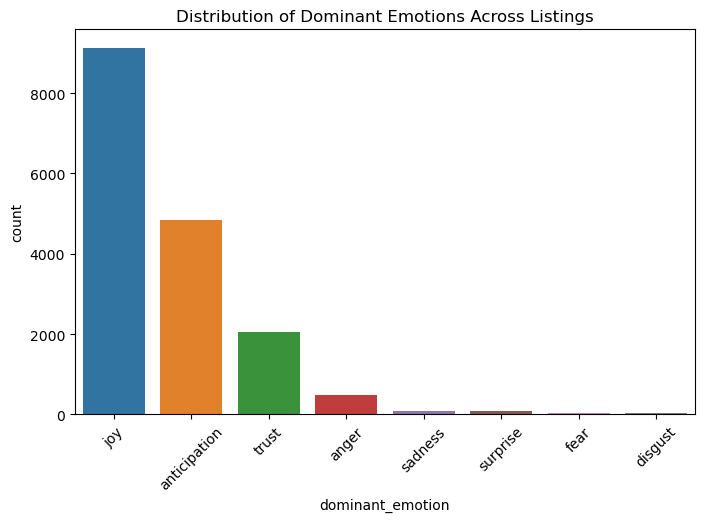

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="dominant_emotion", order=df["dominant_emotion"].value_counts().index)
plt.title("Distribution of Dominant Emotions Across Listings")
plt.xticks(rotation=45)
plt.show()

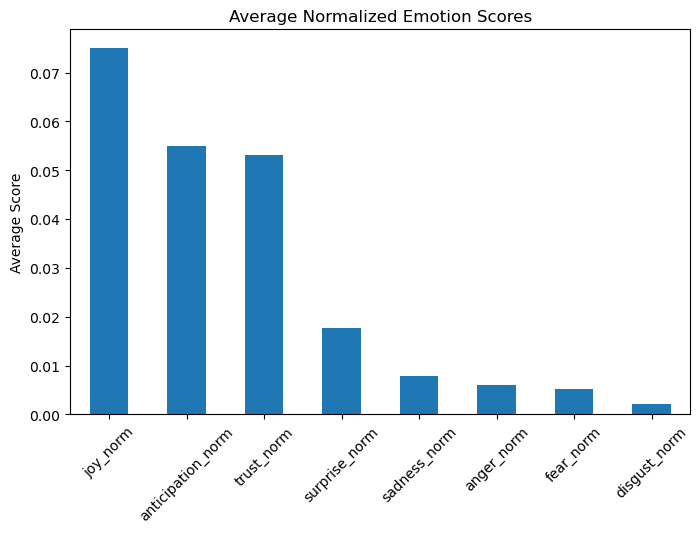

In [157]:
avg_emotions = df[emotion_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_emotions.plot(kind="bar")
plt.title("Average Normalized Emotion Scores")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

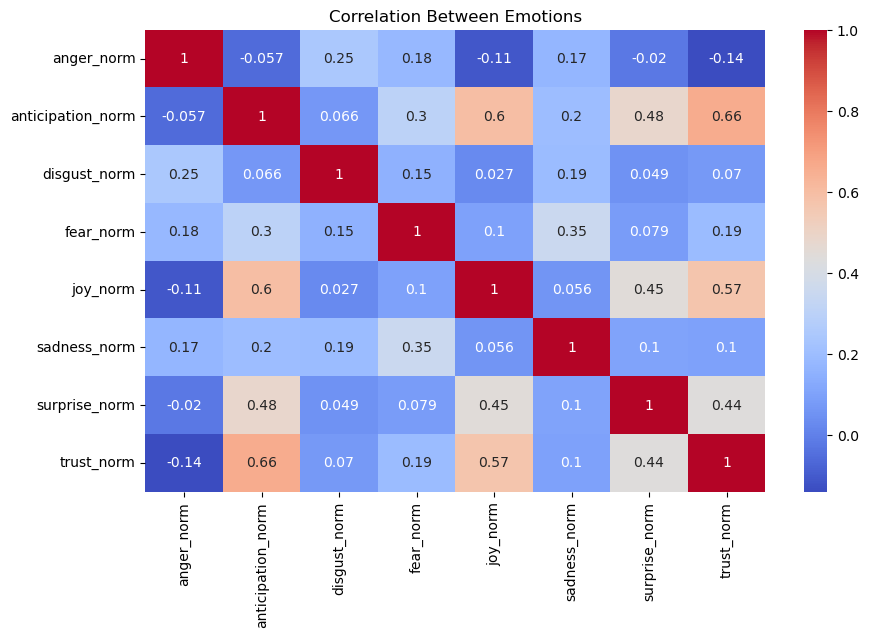

In [158]:
plt.figure(figsize=(10,6))
sns.heatmap(df[emotion_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Emotions")
plt.show()

In [159]:
df["has_ocean_view"] = df["vibe_keywords_pretty"].apply(
    lambda x: any("ocean view" in phrase for phrase in x)
)

df.groupby("has_ocean_view")["joy_norm"].mean()

has_ocean_view
False    0.074852
True     0.078966
Name: joy_norm, dtype: float64

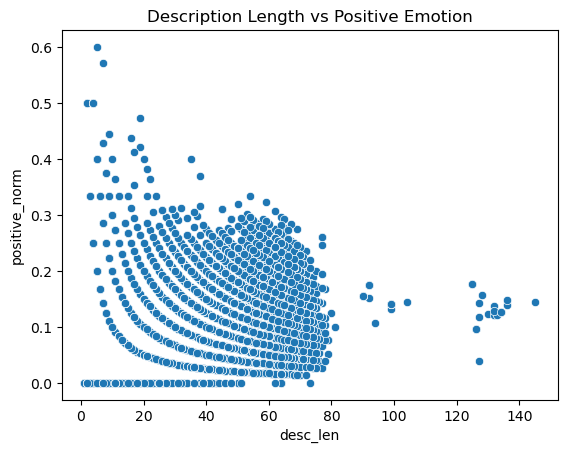

In [160]:
df["desc_len"] = df["emotion_tokens"].apply(len)

sns.scatterplot(data=df, x="desc_len", y="positive_norm")
plt.title("Description Length vs Positive Emotion")
plt.show()